# oil-price-pgm

**Author:** Sana Ur Rehman Arain

**Profession:** Data Scientist | Data Analyst  

**Created:** June 2026  

---

## Copyright & Usage Notice

This project is an original work created by **Sana Ur Rehman Arain** for educational purposes, 
professional portfolio development, and showcasing data science skills.

You may view this project for learning and reference purposes. However, 
you may not copy, reproduce, redistribute, publish, or claim this work as 
your own without explicit permission and proper **credit** to the author.

If you use any part of this project, please provide appropriate attribution.

© 2026 Sana Ur Rehman Arain. All rights reserved.

## Citation

If you reference or build upon this project, please provide appropriate
credit to the original author.

For citation information, see the project's README and CITATION.cff file.

# Steps 3, 4, & 5

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork 
from pgmpy.estimators import HillClimbSearch, BIC
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df_stationary = pd.read_csv('df_stationary.csv', index_col=0, parse_dates=True)
print("Data loaded successfully! Shape:", df_stationary.shape)

Data loaded successfully! Shape: (316, 7)


--- STEP 3 & 4: RE-RUNNING BAYESIAN NETWORK & VALIDATION ---
Training Set Size: 252 months
Testing Set Size: 32 months


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learning network parameters using Maximum Likelihood Estimation...

--- STEP 5: INTERPRETING RESULTS (FORECASTING) ---
Forecasting out-of-sample data...


  0%|          | 0/28 [00:00<?, ?it/s]


=> OUT-OF-SAMPLE FORECASTING ACCURACY: 62.50%
Confusion Matrix:
True Negatives: 8 | False Positives: 9
False Negatives: 3 | True Positives: 12


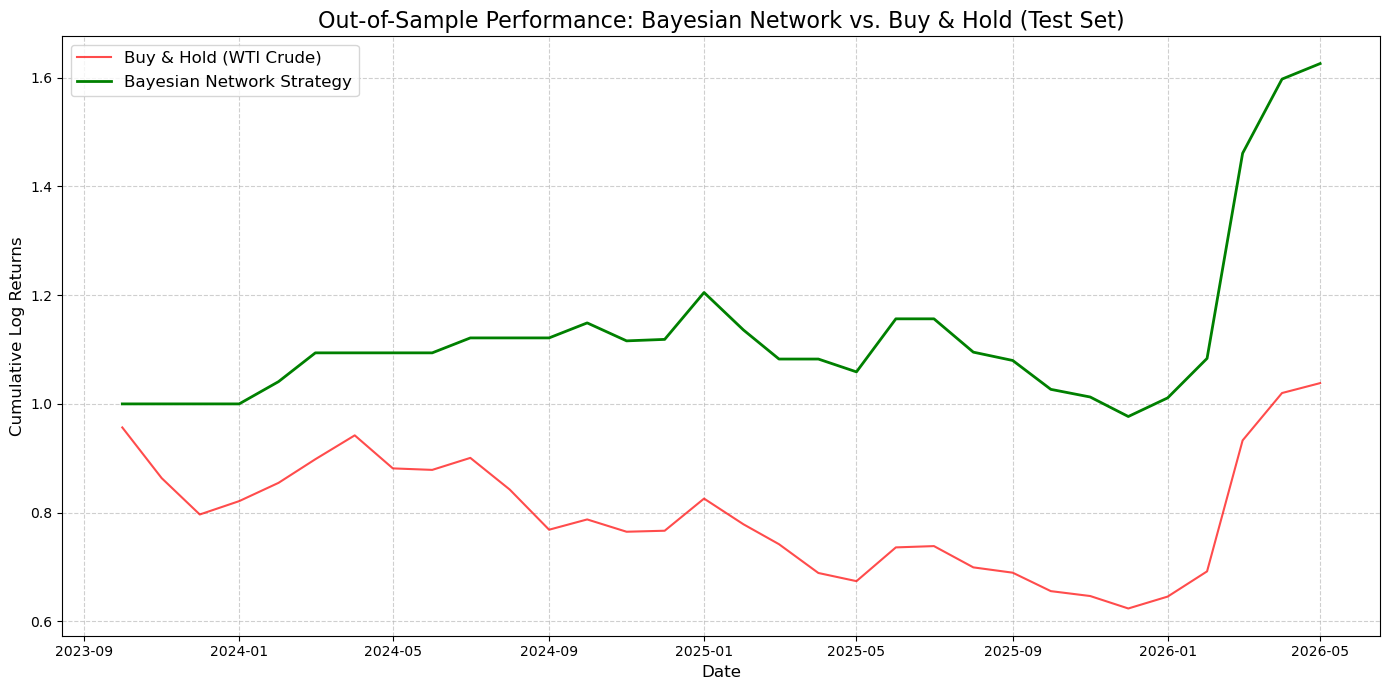

In [9]:
print("--- STEP 3 & 4: RE-RUNNING BAYESIAN NETWORK & VALIDATION ---")

# 1. Discretize the Data (Binary: 1 for Up, 0 for Down)
df_discrete = (df_stationary > 0).astype(int)

# 2. Split the Data (80% Train, 10% Validation, 10% Test)
train_idx = int(len(df_discrete) * 0.8)
test_idx = int(len(df_discrete) * 0.9)

train_data = df_discrete.iloc[:train_idx]
test_data = df_discrete.iloc[test_idx:]
test_actual_returns = df_stationary['WTI_Oil_Price'].iloc[test_idx:] 

print(f"Training Set Size: {len(train_data)} months")
print(f"Testing Set Size: {len(test_data)} months")

# 3. Re-run Structure Learning (Hill Climb Search) on Training Data
hc = HillClimbSearch(train_data)
best_model_structure = hc.estimate(scoring_method=BIC(train_data))

# 4. Initialize and Train the Bayesian Network Parameters
print("Learning network parameters using Maximum Likelihood Estimation...")
model = DiscreteBayesianNetwork(best_model_structure.edges())

# <--- THE FIX: Explicitly add all variables as nodes, even if Hill Climb deleted their causal arrows!
model.add_nodes_from(train_data.columns) 

model.fit(train_data) 

print("\n--- STEP 5: INTERPRETING RESULTS (FORECASTING) ---")

# 5. Predict the Testing Set
# We drop the target variable (WTI_Oil_Price) so the model has to guess it blindly
test_features = test_data.drop(columns=['WTI_Oil_Price'])
print("Forecasting out-of-sample data...")

predictions = model.predict(test_features)
predictions.index = test_data.index

# 6. Calculate Accuracy
actual_states = test_data['WTI_Oil_Price']
predicted_states = predictions['WTI_Oil_Price']

accuracy = accuracy_score(actual_states, predicted_states)
conf_matrix = confusion_matrix(actual_states, predicted_states)

print(f"\n=> OUT-OF-SAMPLE FORECASTING ACCURACY: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(f"True Negatives: {conf_matrix[0][0]} | False Positives: {conf_matrix[0][1]}")
print(f"False Negatives: {conf_matrix[1][0]} | True Positives: {conf_matrix[1][1]}")

# 7. Develop Graphical Display (Cumulative Returns / Equity Curve)
strategy_returns = pd.Series(np.where(predicted_states == 1, test_actual_returns, 0), index=test_actual_returns.index)

cumulative_market = (1 + test_actual_returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(cumulative_market.index, cumulative_market, label='Buy & Hold (WTI Crude)', color='red', alpha=0.7)
plt.plot(cumulative_strategy.index, cumulative_strategy, label='Bayesian Network Strategy', color='green', linewidth=2)

plt.title('Out-of-Sample Performance: Bayesian Network vs. Buy & Hold (Test Set)', fontsize=16)
plt.ylabel('Cumulative Log Returns', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()